# Session 6 Lab



## Part A —  Basic Conditionals

In [4]:
from google.colab import files
import pandas as pd
uploaded = files.upload()  # choose smoker_flu.csv from your laptop
df = pd.read_csv(next(iter(uploaded)))
df.head()

Saving smoker_flu.csv to smoker_flu.csv


,smoker,flu
0,No,Yes
1,Yes,No
2,No,No
3,No,Yes
4,No,Yes


Uusing the file smoker_flu.csv, compute:

- P(A)
- P(B)
- P(A|B)
- P(B|A)
- P(B|Ac)

Is flu independent of smoking?

In [11]:
#First you can transform the data to have the count:
counts = pd.crosstab(df['smoker'], df['flu'])
display(counts)


flu,No,Yes
smoker,,
No,680,120
Yes,140,60


In [16]:
#Now that you have the counts, you can obtain the proba
probs = counts/df.shape[0]
display(probs)


flu,No,Yes
smoker,,
No,0.68,0.12
Yes,0.14,0.06


In [15]:
#Now derive the probability of the event A and B
#Can use use .loc sometimes

P_A = probs.loc['Yes'].sum()
P_B = probs['Yes'].sum()


print("P(A) =", P_A)
print("P(B) =", P_B)

P(A) = 0.2
P(B) = 0.18


In [18]:
P_AnB=probs.loc['Yes','Yes']
P_BnA=P_AnB

P_BnAc=probs.loc['No','Yes']

P_A_given_B = P_AnB / P_B
P_B_given_A = P_BnA / P_A
P_B_given_Ac = P_BnAc / (1-P_A)


print("P(A|B) =", P_A_given_B)
print("P(B|A) =", P_B_given_A)
print("P(B|A^c) =", P_B_given_Ac)
print("Interpretation: Flu depends on Smoking since P(B|A)=0.30 ≠ P(B)=0.18.")

P(A|B) = 0.3333333333333333
P(B|A) = 0.3
P(B|A^c) = 0.15
Interpretation: Flu depends on Smoking since P(B|A)=0.30 ≠ P(B)=0.18.


## Part B — Convergence of Sample Proportions

 Suppose a coin has probability p of falling heads
up. If we flip the coin many times, we would expect the proportion of
heads to be near p.

- Take p = .3 and n = 1, 000 and simulate n coin flips.
- Plot the proportion of heads as a function of n.
- Repeat for p = .03.

What do you remark?

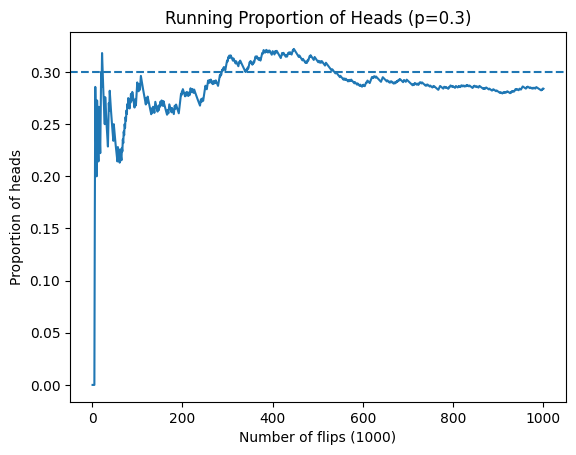

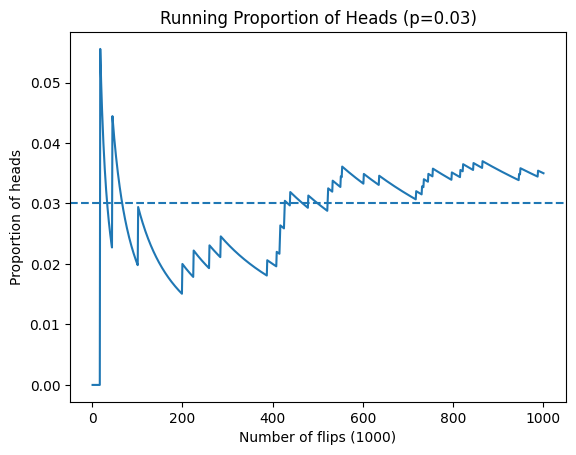

In [27]:
import numpy as np, random
import matplotlib.pyplot as plt

def run_simulation(p, n):

  #Generate n random number
  nums = np.random.rand(n)

  toss=np.where(nums<p,1,0)
  #Take the cumulative sum and divide by the number of event
  running=np.cumsum(toss)/np.arange(1,n+1)


  plt.figure()
  plt.plot(range(1, n+1), running)
  plt.axhline(p, linestyle="--")
  plt.title("Running Proportion of Heads (p=%s)"%p)
  plt.xlabel("Number of flips (%s)"%n)
  plt.ylabel("Proportion of heads")
  plt.show()

run_simulation(0.3, 1000)
run_simulation(0.03, 1000)

**Comment:** With smaller p, early variability is larger and the curve stabilizes more slowly, but it still tends toward p.

## Part C — Simulating Conditional Probabilities

Here we will get some experience simulating conditional probabilities. Consider tossing a fair die.

- **A = {2, 4, 6}**
- **B = {1, 2, 3, 4}**.

First derive theorical probabilities

- **P(A)**
- **P(B)**
- and **P(A∩B)**.

Are A anB independent?
         
         
**Simulate** draws from the sample space and verify

- Create a die and compare the probability you obtain with the theoritical ones.

If you want a difference smaller than 1%, what is the minumum simulation you need?



In [39]:
# Theorical

A = {2,4,6}
B = {1,2,3,4}

#Derive the different probabilities
P_A=len(A)/6
P_B=len(B)/6

P_AnB=len(A&B)/6

print("Theory:   Probability of A: %0.2f"%P_A)
print("Theory:   Probability of B: %0.2f"%P_B)
print("Theory:   Probability of AnB: %0.2f"%P_AnB)


if P_A*P_B==P_AnB:
  print("A and B are independent")
else:
  print("A and B are not independent")

Theory:   Probability of A: 0.50
Theory:   Probability of B: 0.67
Theory:   Probability of AnB: 0.33
A and B are independent


In [51]:
#Create a simulation

import random

def die(N):
  rolls= np.random.randint(1, 7, size=N)
  return rolls

def simulation(N):

  rolls=die(N)

  A_occ = sum(r in A for r in rolls)
  B_occ = sum(r in B for r in rolls)
  AB_occ = sum((r in A) and (r in B) for r in rolls)


  Phat_A = A_occ / N
  Phat_B = B_occ / N
  Phat_AnB = AB_occ / N


  print("Simu:   Probability of A: %0.3f"%Phat_A)
  print("Simu:   Probability of B: %0.3f"%Phat_B)
  print("Simu:   Probability of AnB: %0.3f"%Phat_AnB)


  P_A=0.5
  P_B=0.67
  P_AnB=0.33

  if (np.abs(P_A-Phat_A)<0.01) & (np.abs(P_B-Phat_B)<0.01) & (np.abs(P_AnB-Phat_AnB)<0.01):
    print('You simulated enough with N=%s'%N)
  else:
    print('You need to simulate more')

simulation(250)


Simu:   Probability of A: 0.440
Simu:   Probability of B: 0.652
Simu:   Probability of AnB: 0.280
You need to simulate more


Now, redo everything but for two events C and D that are not independent.

First, you need to find those events

In [56]:
C = {2,4,6}
D = {4,5,6}

#Derive the different probabilities
P_C=len(C)/6
P_D=len(D)/6

P_CnD=len(C&D)/6

print("Theory:   Probability of C: %0.2f"%P_C)
print("Theory:   Probability of D: %0.2f"%P_D)
print("Theory:   Probability of CnD: %0.2f"%P_CnD)


if P_C*P_D==P_CnD:
  print("C and D are independent")
else:
  print("C and D are not independent")

def simulation(N):

  rolls=die(N)

  C_occ = sum(r in C for r in rolls)
  D_occ = sum(r in D for r in rolls)
  CD_occ = sum((r in C) and (r in D) for r in rolls)


  Phat_C = C_occ / N
  Phat_D = D_occ / N
  Phat_CnD = CD_occ / N


  print("Simu:   Probability of C: %0.3f"%Phat_C)
  print("Simu:   Probability of D: %0.3f"%Phat_D)
  print("Simu:   Probability of CnD: %0.3f"%Phat_CnD)


  P_C=len(C)/6
  P_D=len(D)/6

  P_CnD=len(C&D)/6

  if (np.abs(P_C-Phat_C)<0.01) & (np.abs(P_D-Phat_D)<0.01) & (np.abs(P_CnD-Phat_CnD)<0.01):
    print('You simulated enough with N=%s'%N)
  else:
    print('You need to simulate more')

simulation(25000)

Theory:   Probability of C: 0.50
Theory:   Probability of D: 0.50
Theory:   Probability of CnD: 0.33
C and D are not independent
Simu:   Probability of C: 0.499
Simu:   Probability of D: 0.500
Simu:   Probability of CnD: 0.333
You simulated enough with N=25000
